# RF IO
This example controls the high speed DACs and ADCs (14-bit, 125 MSa/s) to generate and acquire a pair of amplitude sweeps at 5.0 MHz and 2.5 MHz.

Required hardware connection (see [README](../README.md) for IO Names and Pin Mapping):
*  SMA cable between rf_out_0 <-> rf_in_0
*  SMA cable between rf_out_1 <-> rf_in_1



### Imports

In [1]:
import time 
import numpy as np
from matplotlib import pyplot as plt
from redpitaya_io_sync.device.rp_125_14_z7010 import Rp_125_14_Z7010
from redpitaya_io_sync.sequence import IoSequence
from redpitaya_io_sync.frame import IoSyncFrame
from redpitaya_io_sync.io.sync import TriggerSource
from redpitaya_io_sync.io.scope import ScopeSource

### Device instances

In [2]:
rp_0 = Rp_125_14_Z7010(ip="192.168.1.143", label="rp_0")

### IO Sequences & IO Frames instances

In [3]:
seq = IoSequence(device_list=[rp_0])
fr_0 = IoSyncFrame(device_type=Rp_125_14_Z7010, trig=None)
fr_1 = IoSyncFrame(device_type=Rp_125_14_Z7010, trig=None)

### Frame definitions 


In [4]:
#FRAME O (ramp RF amplitude up)
fr_0.reset()
fr_0.scope_0.source(ScopeSource.RF_IN_0)
fr_0.scope_1.source(ScopeSource.RF_IN_1)
fr_0.scope_0.decimation(1)
fr_0.scope_1.decimation(1)
fr_0.scope_0.acquire(1000, label="acq_0", run_async=True)
fr_0.scope_1.acquire(1000, label="acq_1", run_async=True)

fr_0.rf_out_0.frequency(5e6)
fr_0.rf_out_1.frequency(2.5e6)

for ampl_0 in np.linspace(0, 0.5, 100):
    fr_0.rf_out_0.amplitude(ampl_0)

for ampl_1 in np.linspace(0, 0.5, 500):
    fr_0.rf_out_1.amplitude(ampl_1)
    
fr_0.delay(250)


#FRAME 1  (ramp RF amplitude down)
fr_1.reset()
for ampl in np.linspace(0.5, 0, 200):
    fr_1.rf_out_0.amplitude(ampl)
    fr_1.rf_out_1.amplitude(ampl)

### Sequence definition

In [5]:
seq.reset()
seq.add_frame(frame=fr_0, device=rp_0, label="ramp up")
seq.add_frame(frame=fr_1, device=rp_0, label="ramp down")

print(seq.sequence_description())

+--------------------+
| rp_0@192.168.1.143 |
+--------------------+
| ramp up            |
| ramp down          |
+--------------------+
NOTE: Frames with (*) are triggered by external trigger source.



### Upload & Run sequence

In [6]:
seq.upload()
seq.start()
while not seq.is_done():
    if seq.is_error():
        print("Sequence error. Please check status.")
        break
    time.sleep(0.01)


In [7]:
seq.get_status()

{'rp_0@192.168.1.143': {'enabled': True,
  'done': True,
  'error': False,
  'current_frame': 'ramp down',
  'io': {'rf_out_0': {'error': False, 'done': True},
   'rf_out_1': {'error': False, 'done': True},
   'digital_io_0': {'error': False, 'done': True},
   'digital_io_1': {'error': False, 'done': True},
   'digital_io_2': {'error': False, 'done': True},
   'digital_io_3': {'error': False, 'done': True},
   'analog_out_0': {'error': False, 'done': True},
   'analog_out_1': {'error': False, 'done': True},
   'analog_out_2': {'error': False, 'done': True},
   'analog_out_3': {'error': False, 'done': True},
   'scope_0': {'error': False, 'done': True},
   'scope_1': {'error': False, 'done': True},
   'led': {'error': False, 'done': True}}}}

In [8]:
seq.stop()

### Plot acquisitions


Device: rp_0@192.168.1.143
Frame: ramp up
Scope: scope_0
Label: acq_0
Time: 2
Decimation: 1
Samples: 1000
Source: RF_IN_0


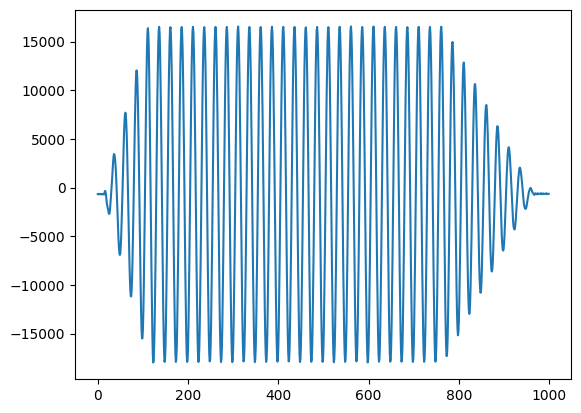

Device: rp_0@192.168.1.143
Frame: ramp up
Scope: scope_1
Label: acq_1
Time: 2
Decimation: 1
Samples: 1000
Source: RF_IN_1


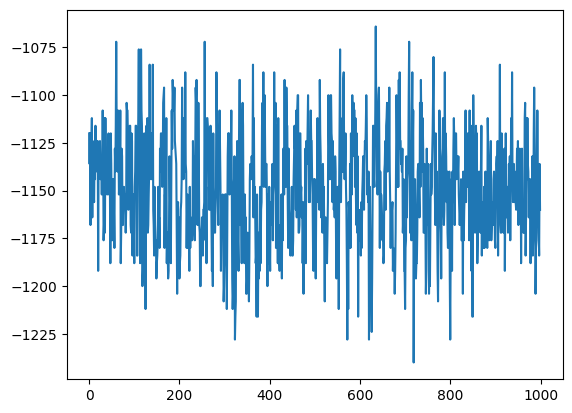

In [9]:
scope_dict = seq.get_scope()

for device_id in scope_dict.keys():
    for frame_label in scope_dict[device_id].keys():
        for scope_label in scope_dict[device_id][frame_label].keys():
            for acq_label in scope_dict[device_id][frame_label][scope_label].keys():
                t = scope_dict[device_id][frame_label][scope_label][acq_label]["t"]
                dec = scope_dict[device_id][frame_label][scope_label][acq_label]["dec"]
                samples = scope_dict[device_id][frame_label][scope_label][acq_label]["samples"]
                src = scope_dict[device_id][frame_label][scope_label][acq_label]["src"]
                data = scope_dict[device_id][frame_label][scope_label][acq_label]["data"]
                print(f"Device: {device_id}")
                print(f"Frame: {frame_label}")
                print(f"Scope: {scope_label}")
                print(f"Label: {acq_label}")
                print(f"Time: {t}")
                print(f"Decimation: {dec}")
                print(f"Samples: {samples}")
                print(f"Source: {src}")
                plt.figure()
                plt.plot(data)
                plt.show()
    